In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot
import seaborn as sns

In [27]:
#loead dataset in the environment
df = pd.read_csv('/Users/user/Downloads/Auspify Technology/Dataset.csv')

In [28]:
print(df.shape)

(8790, 10)


In [29]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
dtype: object


In [30]:
print(df['type'].value_counts())

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [31]:
print(df['type'].value_counts(normalize=True))

type
Movie      0.696928
TV Show    0.303072
Name: proportion, dtype: float64


Looking at the **Duration** column and how it relates well with the task.
I think, this column will make the task almost trivial, since Movies use "min" and TV Shows use "Season(s)" — the model could just learn to key off the "min" vs "Season" pattern, which isn't really predicting content type as much as reading a label in disguise. I'd suggest we train two versions:

**1.** Without duration — the "honest" model, harder, genuinely tests genre/rating/country signal
**2.** With duration — included afterward just to show the contrast, and to make the leakage concept concrete in your Step 5 comparison

In [32]:
# Version A: "honest" feature set (no duration)
features_v1 = ['listed_in', 'rating', 'release_year', 'country']

# Version B: includes duration, for the leakage ccomparison later
features_v2 = features_v1 + ['duration']

#Quick look at the cardinality/uniqueness before we encode anything
print("Unique ratings:", df['rating'].nunique())
print(df['rating'].value_counts())
print()
print("Unique countries:", df['country'].nunique())
print()
print("Unique listed_in combinations:", df['listed_in'].nunique())

Unique ratings: 14
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

Unique countries: 86

Unique listed_in combinations: 513


In [33]:
from sklearn.preprocessing import MultiLabelBinarizer

#--- Rating: simple one-hot ---

rating_encoded = pd.get_dummies(df['rating'], prefix='rating')

#--- Country: split multi-country springs, then multi-hot encode ---
df['country_list'] = df['country'].apply(lambda x: [c.strip() for c in x.split(',')] if x else [])
mlb_country = MultiLabelBinarizer()
country_encoded = pd.DataFrame(
    mlb_country.fit_transform(df['country_list']),
    columns=[f'country_{c}' for c in mlb_country.classes_],
    index=df.index
)

#--- listed_in: same multi-hot approach ---
df['genre_list'] = df['listed_in'].apply(lambda x: [g.strip() for g in x.split(',')] if x else [])
mlb_genre = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb_genre.fit_transform(df['genre_list']),
    columns=[f'genre_{g}' for g in mlb_genre.classes_],
    index=df.index
)

# --- Combine into final feature set (Version A: no duration) ---
X_v1 = pd.concat([rating_encoded, country_encoded, genre_encoded, df['release_year']], axis=1)

# --- Target --
y = df['type'].map({'Movie': 0, 'TV Show': 1})

print(X_v1.shape)
print(y.value_counts())

(8790, 143)
type
0    6126
1    2664
Name: count, dtype: int64


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_v1, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(7032, 143) (1758, 143)
type
0    0.696957
1    0.303043
Name: proportion, dtype: float64
type
0    0.696815
1    0.303185
Name: proportion, dtype: float64


In [36]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

nb = GaussianNB()
nb.fit(X_train, y_train)

print("All three models trained.")

All three models trained.


In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "Naive Bayes": nb
}

for name, model in models.items():
    preds = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds, target_names=['Movie', 'TV Show']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))


Logistic Regression
Accuracy: 1.0000
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     TV Show       1.00      1.00      1.00       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758

Confusion Matrix:
[[1225    0]
 [   0  533]]

Random Forest
Accuracy: 1.0000
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     TV Show       1.00      1.00      1.00       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758

Confusion Matrix:
[[1225    0]
 [   0  533]]

Naive Bayes
Accuracy: 1.0000
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     TV Show       1.00      1.00      1.00    

In [38]:
import re

def clean_genre(genre_list):
    cleaned = []
    for g in genre_list:
        g_clean = g.replace('TV Shows', '').replace('Movies', '').strip()
        if g_clean:  # drop if it becomes empty after stripping (e.g. "TV Shows" alone)
            cleaned.append(g_clean)
    return cleaned

df['genre_list_clean'] = df['genre_list'].apply(clean_genre)

# Re-encode with the cleaned genre list
mlb_genre_clean = MultiLabelBinarizer()
genre_encoded_clean = pd.DataFrame(
    mlb_genre_clean.fit_transform(df['genre_list_clean']),
    columns=[f'genre_{g}' for g in mlb_genre_clean.classes_],
    index=df.index
)

print(genre_encoded_clean.shape)
print(mlb_genre_clean.classes_)

(8790, 38)
['Action & Adventure' 'Anime Features' 'Anime Series' 'British'
 'Children & Family' 'Classic' 'Classic & Cult TV' 'Comedies' 'Crime'
 'Cult' 'Documentaries' 'Docuseries' 'Dramas' 'Faith & Spirituality'
 'Horror' 'Independent' 'International' "Kids' TV" 'Korean' 'LGBTQ'
 'Music & Musicals' 'Reality TV' 'Romantic' 'Sci-Fi & Fantasy'
 'Science & Nature TV' 'Spanish-Language' 'Sports' 'Stand-Up Comedy'
 'Stand-Up Comedy & Talk Shows' 'TV Action & Adventure' 'TV Comedies'
 'TV Dramas' 'TV Horror' 'TV Mysteries' 'TV Sci-Fi & Fantasy'
 'TV Thrillers' 'Teen' 'Thrillers']


In [39]:
def clean_genre_v2(genre_list):
    cleaned = []
    for g in genre_list:
        g_clean = g.replace('TV Shows', '').replace('Movies', '')
        g_clean = re.sub(r'\bTV\b', '', g_clean)       # remove standalone "TV"
        g_clean = re.sub(r'\bSeries\b', '', g_clean)   # remove standalone "Series"
        g_clean = re.sub(r'\s+', ' ', g_clean).strip()  # collapse extra whitespace
        g_clean = g_clean.strip(' &')  # clean up dangling "&" or spaces left behind
        if g_clean:
            cleaned.append(g_clean)
    return cleaned

df['genre_list_clean'] = df['genre_list'].apply(clean_genre_v2)

mlb_genre_clean = MultiLabelBinarizer()
genre_encoded_clean = pd.DataFrame(
    mlb_genre_clean.fit_transform(df['genre_list_clean']),
    columns=[f'genre_{g}' for g in mlb_genre_clean.classes_],
    index=df.index
)

print(genre_encoded_clean.shape)
print(sorted(mlb_genre_clean.classes_))

(8790, 32)
['Action & Adventure', 'Anime', 'Anime Features', 'British', 'Children & Family', 'Classic', 'Classic & Cult', 'Comedies', 'Crime', 'Cult', 'Documentaries', 'Docuseries', 'Dramas', 'Faith & Spirituality', 'Horror', 'Independent', 'International', "Kids'", 'Korean', 'LGBTQ', 'Music & Musicals', 'Mysteries', 'Reality', 'Romantic', 'Sci-Fi & Fantasy', 'Science & Nature', 'Spanish-Language', 'Sports', 'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows', 'Teen', 'Thrillers']


In [41]:
# Rebuild the dict to reference the freshly retrained models
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "Naive Bayes": nb
}

for name, model in models.items():
    preds = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds, target_names=['Movie', 'TV Show']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))


Logistic Regression
Accuracy: 0.9522
              precision    recall  f1-score   support

       Movie       0.95      0.98      0.97      1225
     TV Show       0.96      0.88      0.92       533

    accuracy                           0.95      1758
   macro avg       0.95      0.93      0.94      1758
weighted avg       0.95      0.95      0.95      1758

Confusion Matrix:
[[1206   19]
 [  65  468]]

Random Forest
Accuracy: 0.9562
              precision    recall  f1-score   support

       Movie       0.96      0.98      0.97      1225
     TV Show       0.95      0.91      0.93       533

    accuracy                           0.96      1758
   macro avg       0.95      0.94      0.95      1758
weighted avg       0.96      0.96      0.96      1758

Confusion Matrix:
[[1198   27]
 [  50  483]]

Naive Bayes
Accuracy: 0.7833
              precision    recall  f1-score   support

       Movie       0.99      0.69      0.82      1225
     TV Show       0.58      0.99      0.73    

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['release_year'] = scaler.fit_transform(X_train[['release_year']])
X_test_scaled['release_year'] = scaler.transform(X_test[['release_year']])

log_reg_scaled = LogisticRegression(max_iter=1000, random_state=42)
log_reg_scaled.fit(X_train_scaled, y_train)

preds = log_reg_scaled.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds, target_names=['Movie', 'TV Show']))

Accuracy: 0.9528
              precision    recall  f1-score   support

       Movie       0.95      0.98      0.97      1225
     TV Show       0.96      0.88      0.92       533

    accuracy                           0.95      1758
   macro avg       0.96      0.93      0.94      1758
weighted avg       0.95      0.95      0.95      1758



In [44]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions for each model on the test set
log_reg_preds = log_reg.predict(X_test)              # unscaled version
log_reg_scaled_preds = log_reg_scaled.predict(X_test_scaled)
rf_preds = rf.predict(X_test)
nb_preds = nb.predict(X_test)

results = {
    "Logistic Regression": log_reg_preds,
    "Random Forest": rf_preds,
    "Naive Bayes": nb_preds,
    "Log Reg (scaled)": log_reg_scaled_preds,
}

comparison_rows = []
for name, preds in results.items():
    comparison_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision (TV Show)": precision_score(y_test, preds, pos_label=1),
        "Recall (TV Show)": recall_score(y_test, preds, pos_label=1),
        "F1 (TV Show)": f1_score(y_test, preds, pos_label=1),
        "Recall (Movie)": recall_score(y_test, preds, pos_label=0),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Accuracy", ascending=False)
comparison_df

,Model,Accuracy,Precision (TV Show),Recall (TV Show),F1 (TV Show),Recall (Movie)
1,Random Forest,0.956200,0.947059,0.906191,0.926174,0.977959
3,Log Reg (scaled),0.952787,0.961066,0.879925,0.918707,0.984490
0,Logistic Regression,0.952218,0.960986,0.878049,0.917647,0.984490
2,Naive Bayes,0.783276,0.584071,0.990619,0.734864,0.693061


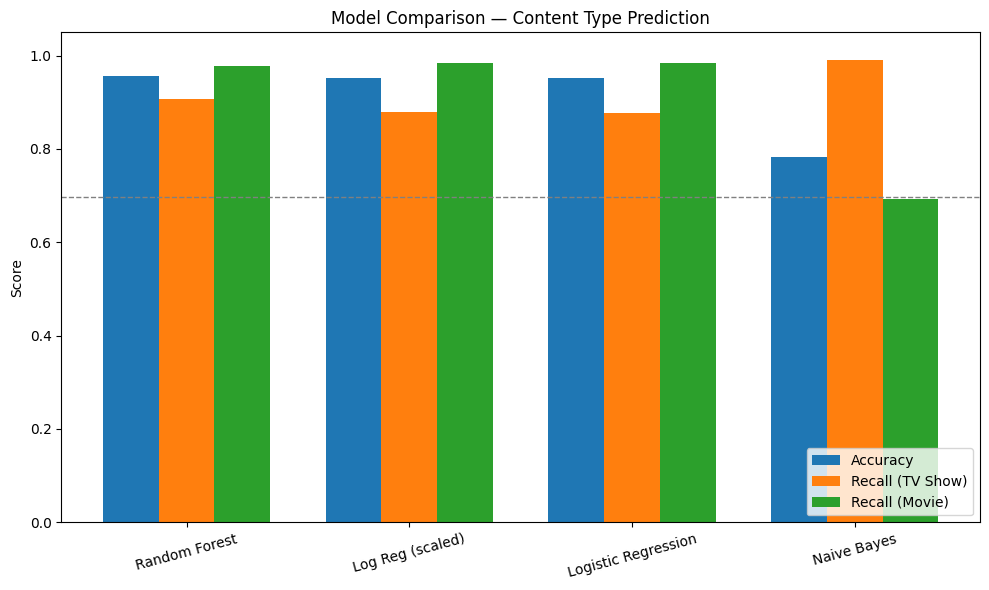

In [45]:
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ["Accuracy", "Recall (TV Show)", "Recall (Movie)"]
models_order = comparison_df["Model"].tolist()

x = np.arange(len(models_order))  # label locations
width = 0.25  # width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics_to_plot):
    values = comparison_df[metric].values
    ax.bar(x + i * width, values, width, label=metric)

ax.set_ylabel("Score")
ax.set_title("Model Comparison — Content Type Prediction")
ax.set_xticks(x + width)
ax.set_xticklabels(models_order, rotation=15)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
ax.axhline(y=0.6969, color='gray', linestyle='--', linewidth=1, label='Baseline (predict Movie always)')

plt.tight_layout()
plt.show()